# Background

Modern companies  collect large amount of customer data, but raw data alone does not provide business values. Marketing campaigns often target all customers equally , which might lead to wasted budget  and low conversion rates.

Customer personality analysis helps businesses understand different types of customers based on demographics, purchasing behaviour and campaign responses. By grouping similar customer together , companies can design personalized marketing stratgies and improve sales efficiency.

## Objective

The goal of this project is to perform customer segmentation using clustering techniques to identify distinct group of customers based on their:
    
    1.Demographics
    2.spending behaviour
    3.purchase channels
    4.response to marketing campaigns
    
The final outcome will help the business:

    1.Identify high value customers
    2.Improve marketing efficiency
    3.Personalize promotions
    4.Increase customer retention
    

## Problem Statement

The company currently market its products to the entire customer database without differentiating between customer types. This results in inefficient marketing spend and low campaign effectiveness.

The company needs a data driven approach to:

    1.Identify different customer segments
    2.Understand customer behaviour and preferences
    3.Target the right customers with the right marketing strategy
    
We will use clustering techniques to group customers with similar characteristics and create actionable insights.

WE NEED TO FIND OUT:


Customer value:

1. Who are the highest spending customers?
2. Which customers generate the most revenue?

Customer behaviour:

3. which customer purchase frequently?
4. Which customers are inactive and at risk of churn?

Product Preferences:

5. Which customer groups prefer which products?
6. Do high high income customers buy different products?

Marketing Effectiveness:

7. Which customers responds to campaign?
8. Which customers buy only during discounts?

Channel Preferences:

9. Which customers prefer online shopping?
10. Which customer prefer store/Offline purchase?

This Project will use Data analytics and machine learning techniques to transform raw customer data into meaningfull customer segments. The insights generated will enable the company to shift from mass marketting to targetted marketing, improving both customer satistfaction and business profitability.

# Data Audit / Initial Exploration

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)

In [183]:
df = pd.read_excel('marketing_campaign.xlsx')
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,2012-11-13,34,235,65,164,50,49,27,4,7,3,7,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,2013-05-08,32,76,10,56,3,1,23,2,4,0,4,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,2013-06-06,19,14,0,24,3,3,2,1,3,0,2,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,2014-03-13,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,3,11,0


In [184]:
df.shape

(2240, 29)

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [186]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274


#### Quick Insights

From above stats we found out that  Z_costContact  and Z_revenue have  standard deviation of 0 means every single customer have the exact same value. This adds Zero information to our model. Dropping them is a good practice here.

Other columns have some inconsistancies such as outliers:

The income column has a suspiciously rich person who has salary of 666666. which might seem like a dummy data. the person probably didnt want to reveal his salary . majority or 75% of the customers are below the 68522 threshold of salary. 
The age also has minimum of 1893 as year of birth which is highly unlikely that the person in question is buying  wine or gold being 100 or more years old. We need to treat these outliers accordingly. Perhaps the person meant to enter 1993. The age has std dev of almost 12 meaning we have cusomers in between age of 1956 to 1980 looking at the average 1968. which tells us that there is a extreme outlier in the year_birth column.

The recency is maximum 99 , which indicates that the  customers  has the purchasing range of 0 - 100 days.

campaign responses are low based on the mean ranging from 0.01-0.07 which indicates very few customers accept campaigns.

Purchase visits also looks realistic since 20 web visits per 1-2 month is realistic.

Education and marital status has some inconsistancies since they are object data types , one is ordinal categorical feature while other is nominal feature.

Less than 1% customers complained in past 2 years


In [187]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [188]:
# Checking if any Duplicate entries
df.duplicated().sum()

0

In [189]:
# Checking the unique values in education and marital status

print(f"Number of unique values in Education: ",df['Education'].nunique())
print(f"Number of unique values in Marital status: ",df['Marital_Status'].nunique())

print(f"unique values in Education: \n",df['Education'].unique())
print(f"unique values in Marital status: \n",df['Marital_Status'].unique())

Number of unique values in Education:  5
Number of unique values in Marital status:  8
unique values in Education: 
 ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
unique values in Marital status: 
 ['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


In [190]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [191]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [192]:
# Checking the id column
df['ID'].nunique()

2240

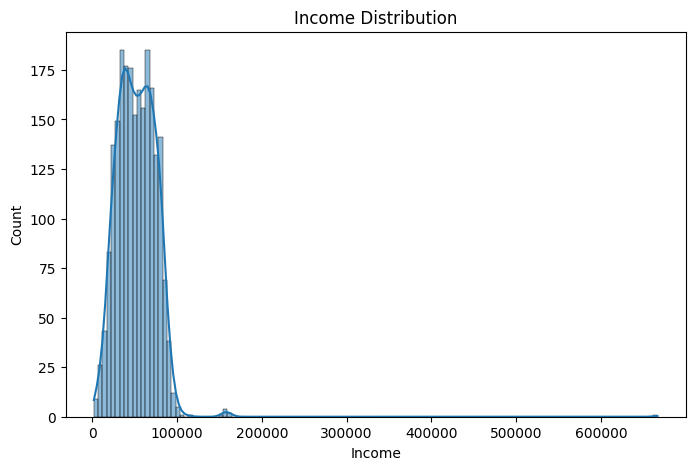

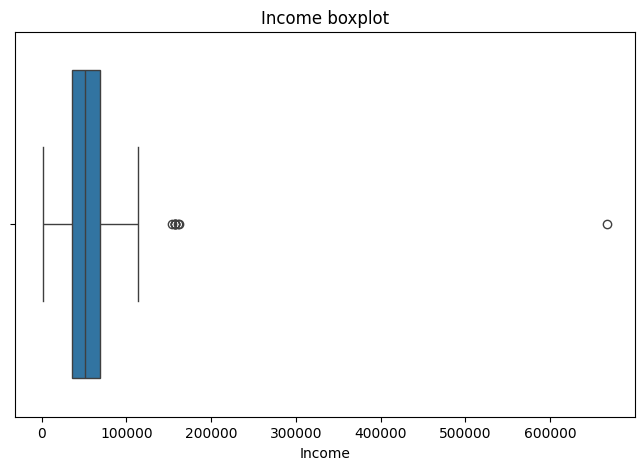

In [193]:
# plotting the income feature distribution 
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], kde=True)
plt.title('Income Distribution')
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(x=df['Income'])
plt.title('Income boxplot')
plt.show()

You can see from above graphs that there are some extreme outliers in the income column. There is an extreme outlier.This data point is making the distribution heavily skewed.

In [194]:
# creating a separate age column and calculating the age
df['Age'] = 2026 - df['Year_Birth']

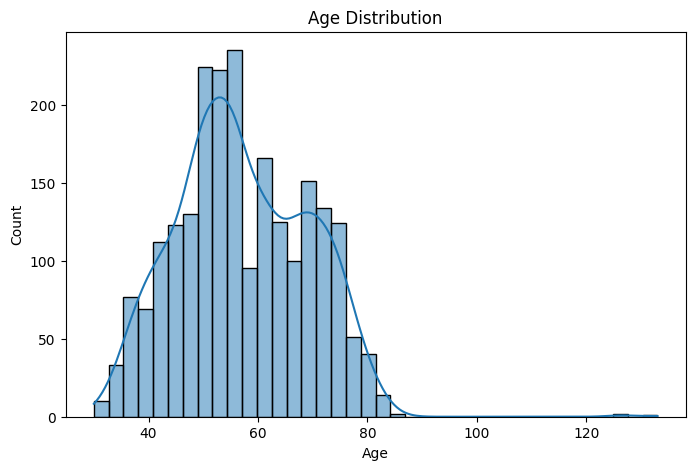

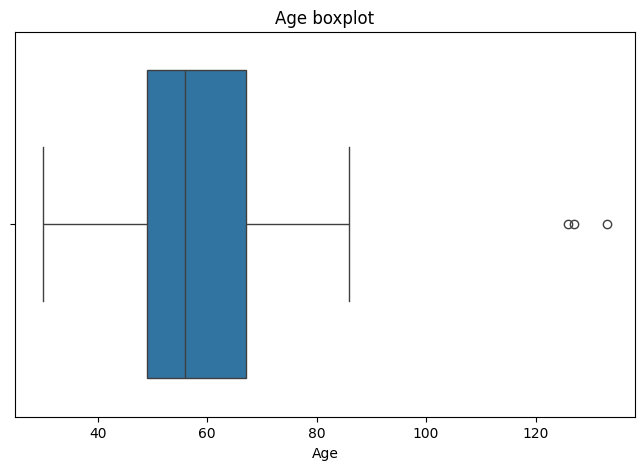

In [195]:
# Visulizing the age distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(x=df['Age'])
plt.title('Age boxplot')
plt.show()

The age column also had some extreme outliers, some are even unrealistic.

# Data Cleaning

In [196]:
# Dropping the Z_costcontact and Z_revenue columns due to Zero Variance

df.drop(['Z_CostContact','Z_Revenue'], axis=1,inplace=True)

In [197]:
#### Handling Missing Values in Inocme and Age Columns ####

In [198]:
# imputing the income column to fill the missing values

df['Income'].fillna(df['Income'].median(), inplace=True)

C:\Users\Shree Hari\AppData\Local\Temp\ipykernel_10952\310090292.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [199]:
# keeping only the realistic ages
df = df[df['Age'] <= 90]

In [200]:
# treating the income outliers

Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

# Replacing any value above the upper bound with  'upper_limit'
df['Income'] = df['Income'].clip(upper=upper_limit)

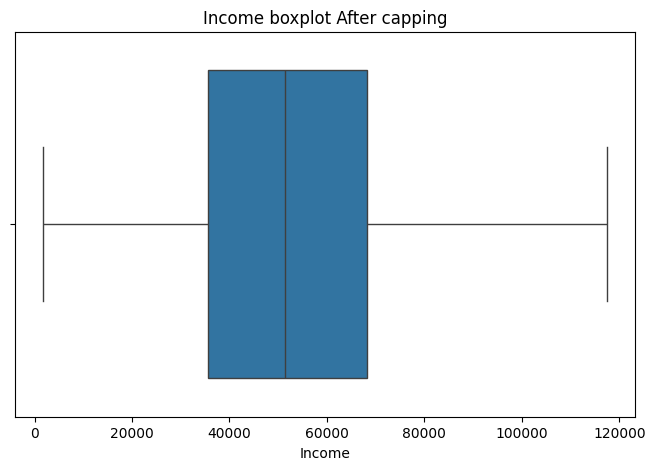

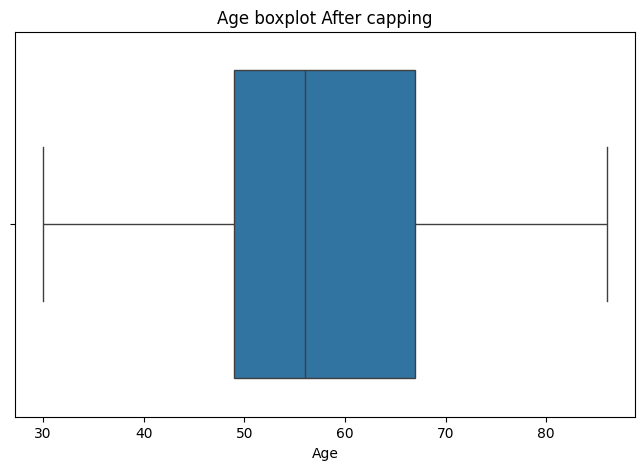

In [201]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Income'])
plt.title('Income boxplot After capping')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Age'])
plt.title('Age boxplot After capping')
plt.show()

In [202]:
# Categorizing marital status as single, partnered, and Prev_married
df['Marital_Status'] = df['Marital_Status'].replace({
    'Married':'Partnered',
    'Together':'Partnered',
    'Single':'Single',
    'Alone':'Single',
    'YOLO':'Single',
    'Absurd':'Single',
    'Divorced':'Previously_Married',
    'Widow':'Previously_Married'
    })


In [203]:
df['Marital_Status'].value_counts()

Marital_Status
Partnered             1443
Single                 486
Previously_Married     308
Name: count, dtype: int64

In [204]:
# categorizing Education level

df['Education'] = df['Education'].replace({
    'Basic':'Undergraduate',
    'Graduation': 'Undergraduate',
    '2n Cycle': 'Postgraduate',
    'Master': 'Postgraduate',
    'PhD': 'Postgraduate'
})

In [205]:
df['Education'].value_counts()

Education
Undergraduate    1181
Postgraduate     1056
Name: count, dtype: int64

In [206]:
# Converting Dt_customers to Datetime to calculate the tenure of a customer and data consitency
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

In [207]:
df['Dt_Customer'].head()

0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]

In [208]:
df['Dt_Customer'].describe()

count                             2237
mean     2013-07-10 05:01:54.260169728
min                2012-07-30 00:00:00
25%                2013-01-16 00:00:00
50%                2013-07-08 00:00:00
75%                2013-12-30 00:00:00
max                2014-06-29 00:00:00
Name: Dt_Customer, dtype: object

#  Exploratory Data Analysis

In [209]:
#Checking the distribution of spending/product  columns
spending_cols = ['MntWines','MntFruits','MntMeatProducts',
                 'MntFishProducts','MntSweetProducts','MntGoldProds']
df[spending_cols].describe()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
count,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000
mean,303.995530,26.270451,166.916853,37.523022,27.068842,43.968708
std,336.574382,39.715972,225.661158,54.639909,41.293949,52.054318
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,1.000000,16.000000,3.000000,1.000000,9.000000
50%,174.000000,8.000000,67.000000,12.000000,8.000000,24.000000
75%,504.000000,33.000000,232.000000,50.000000,33.000000,56.000000
max,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000


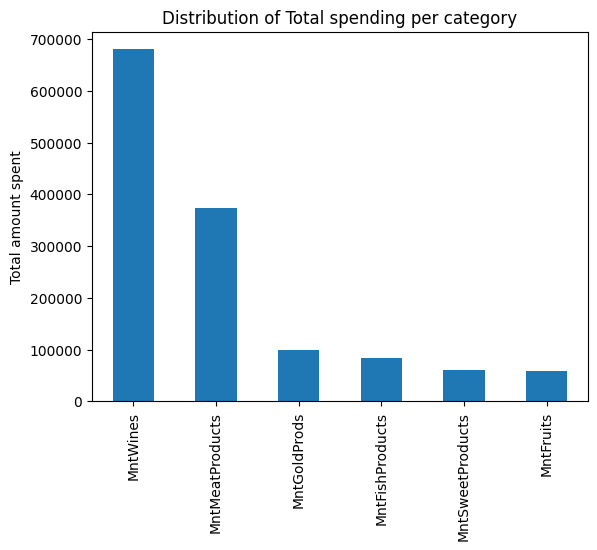

In [210]:
df[spending_cols].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Distribution of Total spending per category')
plt.ylabel('Total amount spent')
plt.show()

 you can see that the amount spent on wines  and meat products by customers is higher than the rest of the products in the last 2 years.

In [211]:
# Creating Total spending column 
df['Total_spending'] = df[spending_cols].sum(axis=1)

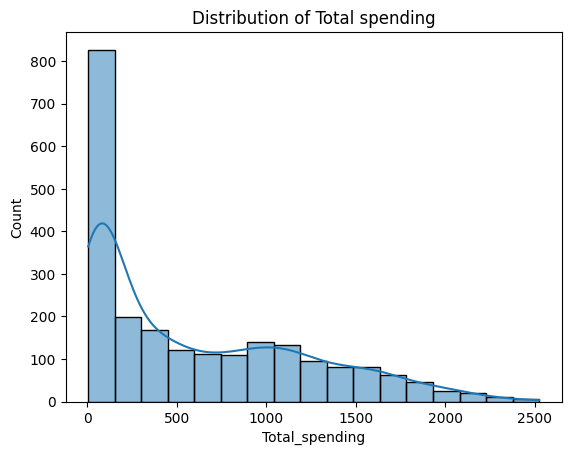

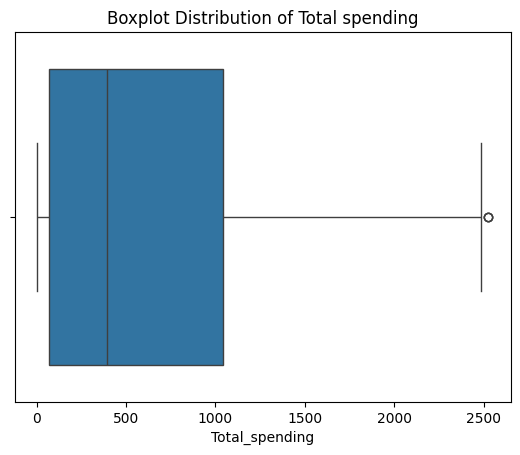

In [212]:
sns.histplot(df['Total_spending'],kde =True)
plt.title('Distribution of Total spending')
plt.show()

sns.boxplot(x=df['Total_spending'])
plt.title('Boxplot Distribution of Total spending')
plt.show()

the total spending column is heavily skewed towars right, There are some spenders who spends higher than the most.

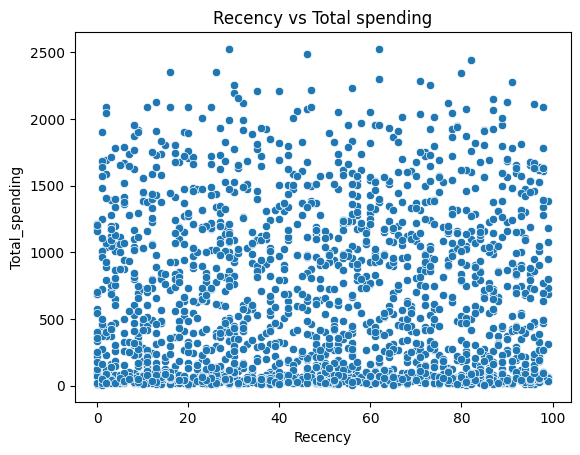

In [213]:
# recency vs total spending - To find out if recent customers spend more or not
sns.scatterplot(x='Recency',y='Total_spending', data=df)
plt.title('Recency vs Total spending')
plt.show()

from above chart it indicates that the relationship between recency vs total spending is non linear and noisy.Some very recent customers and also the older customers spend a lot while there are some  customers who spend very little. The independent nature of recency is usefull for clustering cause it wont dominate the clustering. so we need to pair this with frequency or monitary variable.

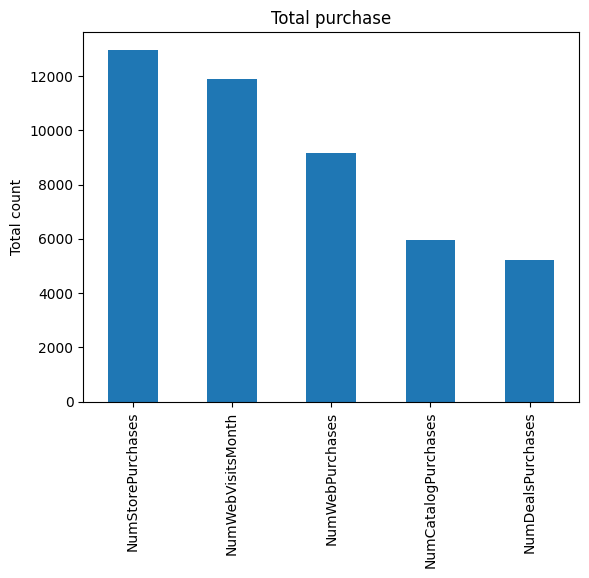

In [214]:
# Distribution of Purchase columns
purchase_cols = ['NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumDealsPurchases',
    'NumWebVisitsMonth']

df[purchase_cols].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total purchase')
plt.ylabel('Total count')
plt.show()

Number of store purchases are all time high . web purchases are also high.while deal purchases are the lowest.This tells us that this business is heavily store driven, web trafic is strong which means digital engagement exist. But web purcheses are lower than the visits indicating low convergion rate.

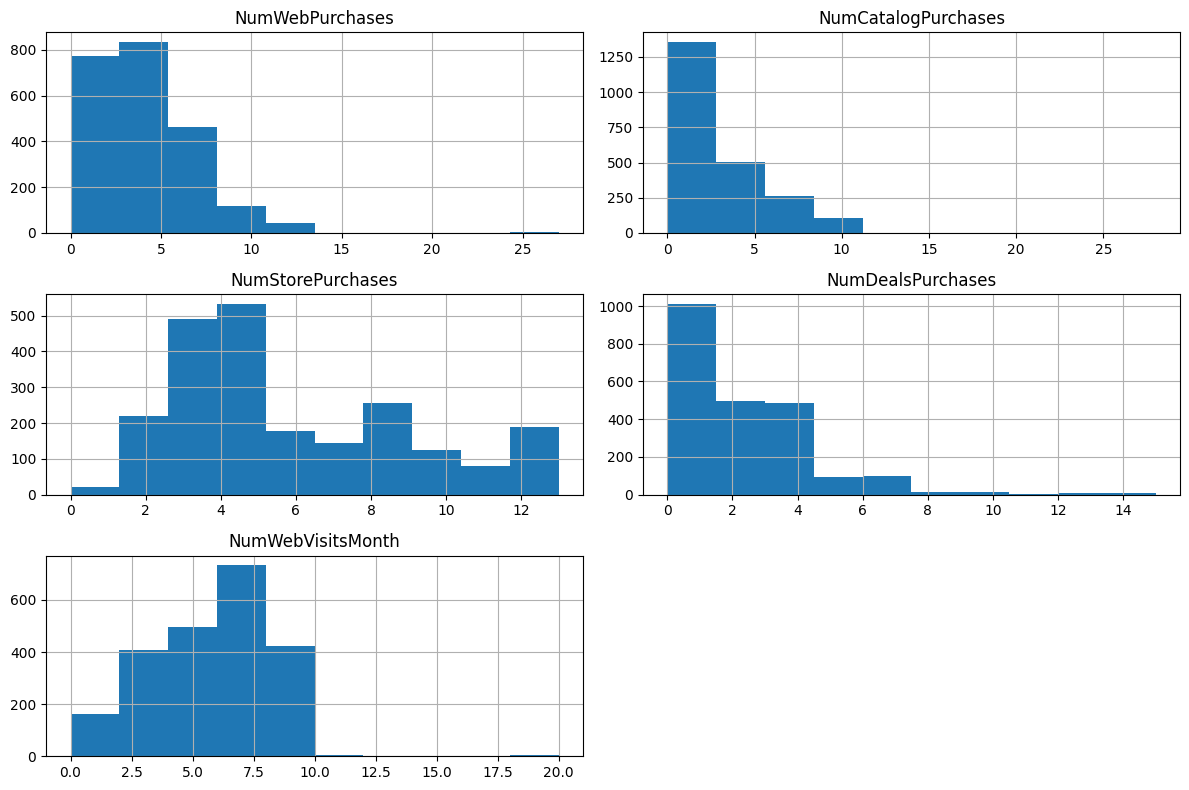

In [215]:
df[purchase_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Most customers make between 0-7 web purcheses, there are very few who are above 10. Catelog purchase are Highly concentrated around 0–5 .In numstore purchase the distribution is more spread, meaning store channel is dominant and consistant. In numdeals purchase many customers have very low values, few heavy deal buyers meaning only the subset of customers are deal driven.

The data suggest the segmentation may form around:

    1.purchase channel  preferences
    2.deal sensitivity
    3.engagement vs conversion
    4.purchasing frequency
    5.spending intensity


In [216]:
# Calculating the time/days since the last customer was enrolled
reference_date = df['Dt_Customer'].max()
df['Customer_Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days

In [217]:
reference_date

Timestamp('2014-06-29 00:00:00')

Above is the last date that one of the  customer's enrollment

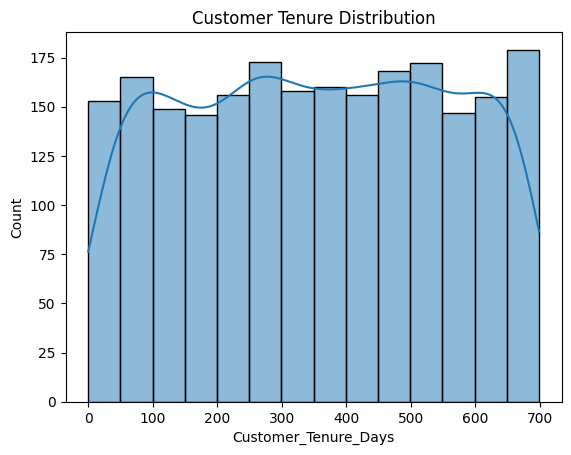

In [218]:
sns.histplot(df['Customer_Tenure_Days'], kde=True)
plt.title("Customer Tenure Distribution")
plt.show()

# Advance EDA  + Feature Engineering

In [219]:
# Creating a new feature 'Total Purchases'
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases'] +
    df['NumDealsPurchases']
)

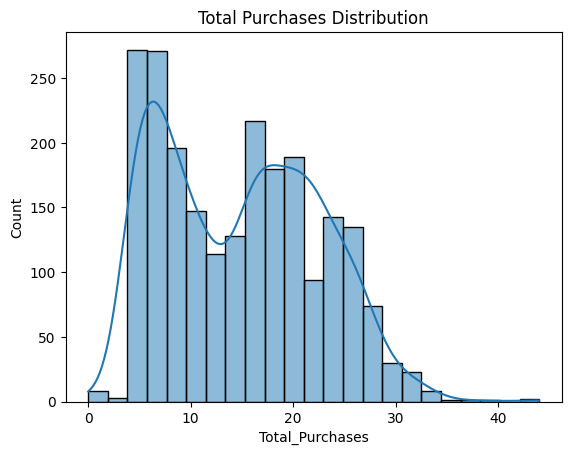

In [220]:
sns.histplot(df['Total_Purchases'], kde=True)
plt.title("Total Purchases Distribution")
plt.show()

AOV = Total revenue / No. of orders placed

In [221]:
# Creating feature  avg order value
df['Avg_Order_Value'] = df['Total_spending'] / df['Total_Purchases']

# Handling the inf and replacing it with 0
df['Avg_Order_Value'].replace([float('inf')], 0, inplace=True)

# handling NaN Values
df['Avg_Order_Value'].fillna(0, inplace=True)

C:\Users\Shree Hari\AppData\Local\Temp\ipykernel_10952\3177320310.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Avg_Order_Value'].replace([float('inf')], 0, inplace=True)
C:\Users\Shree Hari\AppData\Local\Temp\ipykernel_10952\3177320310.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [222]:
df['Avg_Order_Value'].describe()

count    2237.000000
mean       33.253555
std        44.997704
min         0.000000
25%         9.600000
50%        23.352941
75%        45.217391
max      1679.000000
Name: Avg_Order_Value, dtype: float64

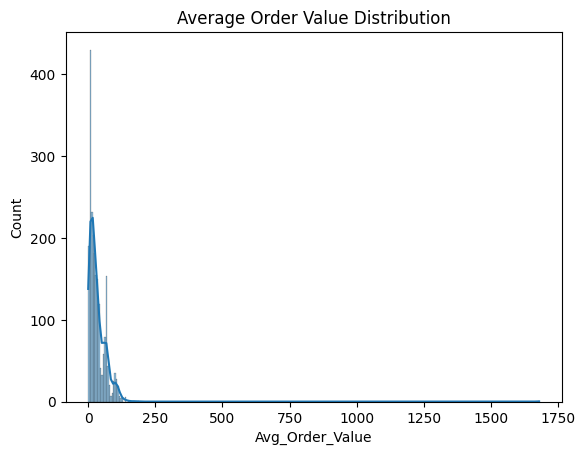

In [223]:
sns.histplot(df['Avg_Order_Value'],kde=True)
plt.title('Average Order Value Distribution')
plt.show()

We can see the distributin has massive skew towards right side. majority of customers clustered at the very low end while tiny fraction of them extends into a massive long tail. You can see half of our customers spend 23  or less per order. but our 75% customers avg order value is below 45 meaning some customers place unnaturally high orders that pulls the means towards them or inflate it, These customers might dominate the revenue. The std dev 44  shows that there is very high variability in the data.

In [224]:
# applying Log transformation

df['Log_Avg_Order_Value'] = np.log1p(df['Avg_Order_Value']) # Log1p safely handle zeroes and negatives

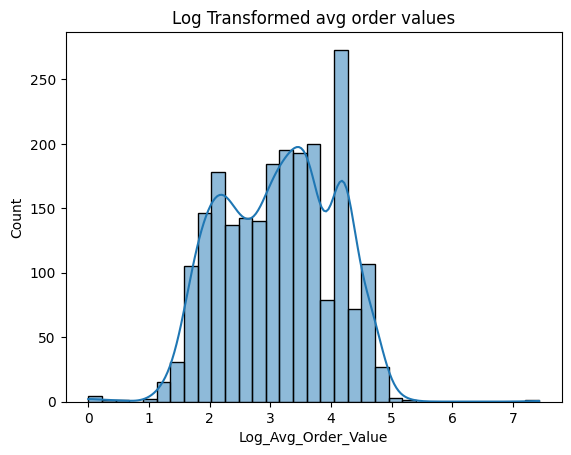

In [225]:
sns.histplot(df['Log_Avg_Order_Value'],kde=True)
plt.title('Log Transformed avg order values')
plt.show()

After applying log transformation you can see the data is less skewed and it is normalized, perfect for the model.

In [226]:
# Finding the discount driven customers

df['Deal_Ratio'] = df['NumDealsPurchases'] / df['Total_Purchases']

# Handling the inf and replacing it with 0
df['Deal_Ratio'].replace([float('inf')], 0, inplace=True)

# handling NaN Values
df['Deal_Ratio'].fillna(0, inplace=True)

C:\Users\Shree Hari\AppData\Local\Temp\ipykernel_10952\64148742.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Deal_Ratio'].replace([float('inf')], 0, inplace=True)
C:\Users\Shree Hari\AppData\Local\Temp\ipykernel_10952\64148742.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [227]:
df['Deal_Ratio'].describe()

count    2237.000000
mean        0.180452
std         0.111315
min         0.000000
25%         0.076923
50%         0.166667
75%         0.250000
max         1.000000
Name: Deal_Ratio, dtype: float64

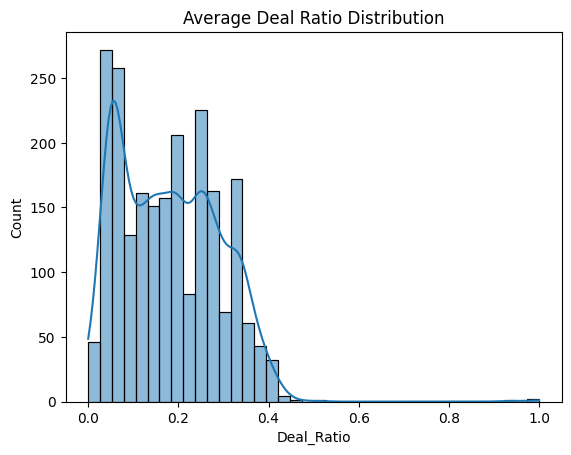

In [228]:
sns.histplot(df['Deal_Ratio'],kde=True)
plt.title('Average Deal Ratio Distribution')
plt.show()

peak1 (0.05 to 0.1):The premiumn customers almost never use the discount, they buy at full price. If we spend discount on these customers , it will be total waste since they are buying at full price anyway.

peak2 (0.2 to 0.3) : The opportunistic people who are around 0.2  to 0.3 use deals for almost more than half their purchases.

peak3 (near  1.0):  AND there are  the bargain hunters who buy only when there is discount. 

In [229]:
# Discovering the web conversion behaviour
df['Web_converion_rate'] = df['NumWebPurchases'] / df['NumWebVisitsMonth']

# Handling the inf and replacing it with 0
df['Web_converion_rate'].replace([float('inf')], 0, inplace=True)

# handling NaN Values
df['Web_converion_rate'].fillna(0, inplace=True)

C:\Users\Shree Hari\AppData\Local\Temp\ipykernel_10952\1254956527.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Web_converion_rate'].replace([float('inf')], 0, inplace=True)
C:\Users\Shree Hari\AppData\Local\Temp\ipykernel_10952\1254956527.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [230]:
df['Web_converion_rate'].describe()

count    2237.000000
mean        1.086077
std         1.328212
min         0.000000
25%         0.333333
50%         0.750000
75%         1.500000
max        27.000000
Name: Web_converion_rate, dtype: float64

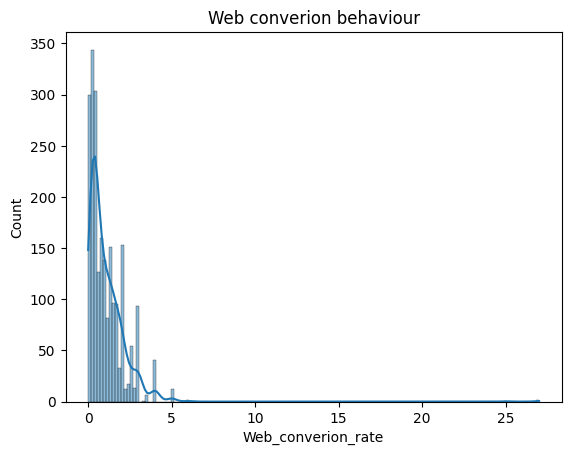

In [231]:
sns.histplot(df['Web_converion_rate'], kde=True)
plt.title('Web converion behaviour')
plt.show()

Including this feature is not good because:

    1.It divides lifetime behavior by monthly behavior.
    2.It creates artificially huge numbers.
    3. It misleads clustering algorithms.

In [232]:
df.drop('Web_converion_rate', axis =1 , inplace=True)

In [233]:
# creating web channel ratio inplace of web conversion rate

df['Web_channel_ratio'] = df['NumWebPurchases'] / df['Total_Purchases']

df['Web_channel_ratio'].fillna(0, inplace=True) # filling NaN

C:\Users\Shree Hari\AppData\Local\Temp\ipykernel_10952\1439551134.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Web_channel_ratio'].fillna(0, inplace=True) # filling NaN


In [234]:
df['Web_channel_ratio'].describe()

count    2237.000000
mean        0.266795
std         0.100267
min         0.000000
25%         0.200000
50%         0.259259
75%         0.333333
max         1.000000
Name: Web_channel_ratio, dtype: float64

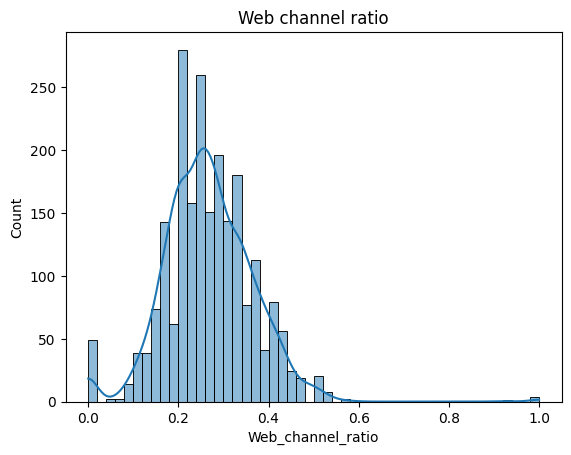

In [235]:
sns.histplot(df['Web_channel_ratio'], kde=True)
plt.title('Web channel ratio')
plt.show()

from above graph -Most customers do 20%–33% of purchases online. some customers are purely online or purely offline.

In [236]:
# Creating children column

df['children'] = df['Kidhome'] + df['Teenhome']

In [237]:
# dropping the redundant features kidhome and teenhome 
df.drop(['Kidhome','Teenhome'], axis=1 , inplace=True)

In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2237 entries, 0 to 2239
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    2237 non-null   int64         
 1   Year_Birth            2237 non-null   int64         
 2   Education             2237 non-null   object        
 3   Marital_Status        2237 non-null   object        
 4   Income                2237 non-null   float64       
 5   Dt_Customer           2237 non-null   datetime64[ns]
 6   Recency               2237 non-null   int64         
 7   MntWines              2237 non-null   int64         
 8   MntFruits             2237 non-null   int64         
 9   MntMeatProducts       2237 non-null   int64         
 10  MntFishProducts       2237 non-null   int64         
 11  MntSweetProducts      2237 non-null   int64         
 12  MntGoldProds          2237 non-null   int64         
 13  NumDealsPurchases     2

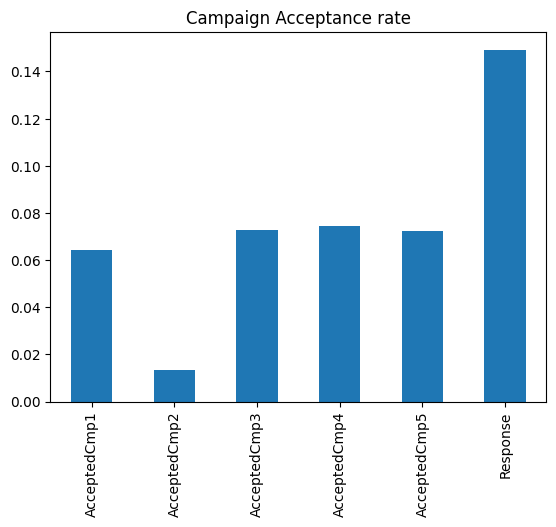

In [239]:
# visualizing campaign columns

campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']

df[campaign_cols].mean().plot(kind='bar')
plt.title('Campaign Acceptance rate')
plt.show()

Acceptance rate for the last campaign is particularly higher than the last 5. may indicate different type of offers for the last campaign

In [240]:
df['Complain'].value_counts(normalize=True)

Complain
0    0.991059
1    0.008941
Name: proportion, dtype: float64

Campaign acceptance rate and compain have low clustering power so including them is unnecessay.

In [241]:
df.describe()

,ID,Year_Birth,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_spending,Customer_Tenure_Days,Total_Purchases,Avg_Order_Value,Log_Avg_Order_Value,Deal_Ratio,Web_channel_ratio,children
count,2237.000000,2237.000000,2237.000000,2237,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000
mean,5590.726419,1968.901654,51854.814037,2013-07-10 05:01:54.260169728,49.104604,303.995530,26.270451,166.916853,37.523022,27.068842,43.968708,2.326777,4.087170,2.662494,5.794367,5.319177,0.072865,0.074654,0.072418,0.064372,0.013411,0.008941,0.149307,57.098346,605.743406,353.790344,14.870809,33.253555,3.140400,0.180452,0.266795,0.950827
min,0.000000,1940.000000,1730.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2829.000000,1959.000000,35523.000000,2013-01-16 00:00:00,24.000000,24.000000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,49.000000,69.000000,181.000000,8.000000,9.600000,2.360854,0.076923,0.200000,0.000000
50%,5455.000000,1970.000000,51381.500000,2013-07-08 00:00:00,49.000000,174.000000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,396.000000,356.000000,15.000000,23.352941,3.192653,0.166667,0.259259,1.000000
75%,8427.000000,1977.000000,68281.000000,2013-12-30 00:00:00,74.000000,504.000000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000,1045.000000,529.000000,21.000000,45.217391,3.833356,0.250000,0.333333,1.000000
max,11191.000000,1996.000000,117418.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,86.000000,2525.000000,699.000000,44.000000,1679.000000,7.426549,1.000000,1.000000,3.000000
std,3245.118591,11.701917,20936.241476,NaN,28.956073,336.574382,39.715972,225.661158,54.639909,41.293949,52.054318,1.932923,2.779461,2.923456,3.250940,2.426386,0.259974,0.262890,0.259237,0.245469,0.115052,0.094152,0.356471,11.701917,601.840466,202.137961,7.676593,44.997704,0.908321,0.111315,0.100267,0.752037


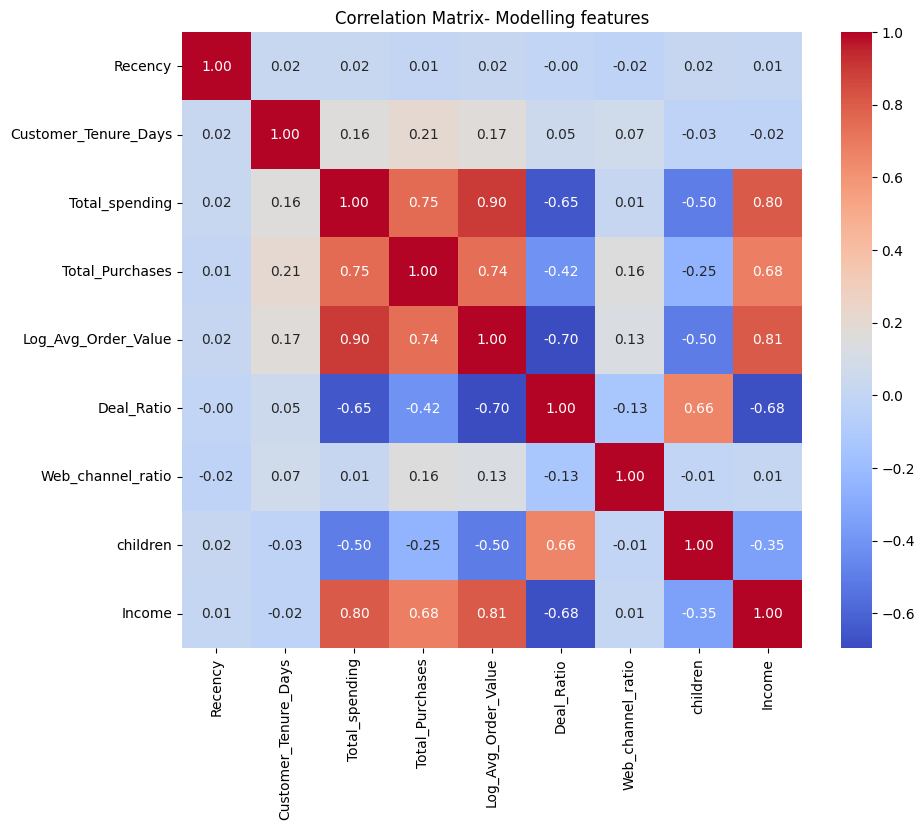

In [242]:
model_candiates = ['Recency','Customer_Tenure_Days','Total_spending',
                   'Total_Purchases','Log_Avg_Order_Value','Deal_Ratio',
                  'Web_channel_ratio','children','Income']

plt.figure(figsize=(10,8))
sns.heatmap(df[model_candiates].corr(), annot=True,cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix- Modelling features')
plt.show()

From the correlation matrix:

    Total_spending : Log_Avg_Order_Value = 0.90
    Income : Log_Avg_Order_Value = 0.81
    Income - Total_spending = 0.80
    Total_spending : Total_Purchases = 0.75

These strong correlations indicate a monetary block where multiple variables represent the same underlying behavior. so including one of them  is the better choice. Including all of them would bias our model and overweight the clustering results. It would reduce the behavioural diversity in the clusters.

Log_Avg_Order_Value and Total_Purchases were retained to represent monetary intensity and purchase frequency separately (FM components).


    1.Recency shows very weak correlation with other variables.
    2.Web_channel_ratio is nearly independent.
    3.Customer_Tenure_Days has only mild relationships.

   These features add new segmentation dimensions rather than reinforcing existing ones.
   
   Deal ratio's correlation with Log_AOV , income and Total spending shows negative correlation, this might indicate that the discount driven customers behave differently than the high value customers. based on this we might be able to find :
   
       1.high premium customers,
       2.discount driven 
       3.and Mixed behaviour segment.
       
 while clsutering is primarily behaviour based children feature was included to add family structure which may influence spending capacity,purchase frequency and deal usage.
 
After performing post-engineering EDA and analyzing the correlation matrix, the following features were selected for clustering:

    Selected Features:
        1.Recency
        2.Customer_Tenure_Days
        3.Total_Purchases ( Frequency- How often )
        4.Log_Avg_Order_Value ( monetary intensity- How much per order)
        5.Deal_Ratio
        6.Web_channel_ratio
        7.Children
        
  

# Model Building and Evaluation

In [243]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from  sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

In [244]:
model_features = ['Recency','Customer_Tenure_Days','Total_Purchases',
                 'Log_Avg_Order_Value','Deal_Ratio','Web_channel_ratio','children']

df_model = df[model_features].copy()

In [245]:
# Scaling the dataset so that it has mean= 0 and std_dev= 1
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)

In [246]:
df_scaled

array([[ 0.30727179,  1.53003815,  1.31978541, ..., -0.54319123,
         0.53075143, -1.26461829],
       [-0.38358403, -1.19148418, -1.15582425, ...,  1.37371307,
        -0.99884256,  1.39542037],
       [-0.79809753, -0.20678792,  0.79860443, ..., -1.19356948,
         1.1387888 , -1.26461829],
       ...,
       [ 1.44718391, -0.98365884,  0.53801394, ..., -1.14852943,
        -1.61138021, -1.26461829],
       [-1.41986777, -0.97871061,  1.05919492, ..., -0.84010304,
        -0.0591109 ,  0.06540104],
       [-0.31449845,  1.32716103, -0.50434802, ...,  0.82913799,
         0.059177  ,  1.39542037]])

### Elbow Method 

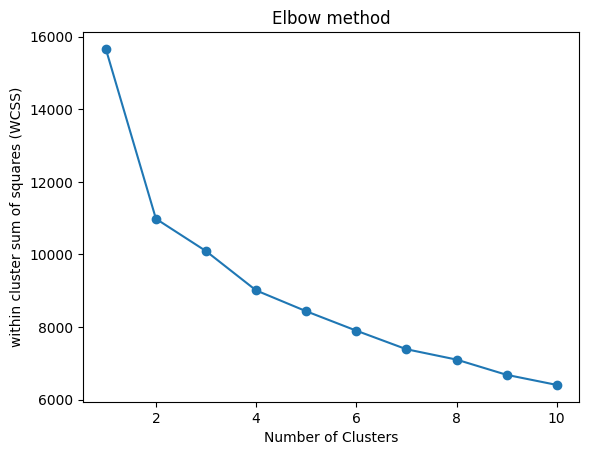

In [247]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state = 42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1,11),wcss, marker = 'o')
plt.xlabel('Number of Clusters')
plt.ylabel('within cluster sum of squares (WCSS)')
plt.title('Elbow method')
plt.show()


### silhouette interpretation

In [248]:
silhouette_results = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_results[k] = score

silhouette_df = pd.DataFrame.from_dict(
    silhouette_results, 
    orient='index', 
    columns=['Silhouette_Score']
)

silhouette_df

,Silhouette_Score
2,0.272351
3,0.199665
4,0.166780
5,0.152663
6,0.155074


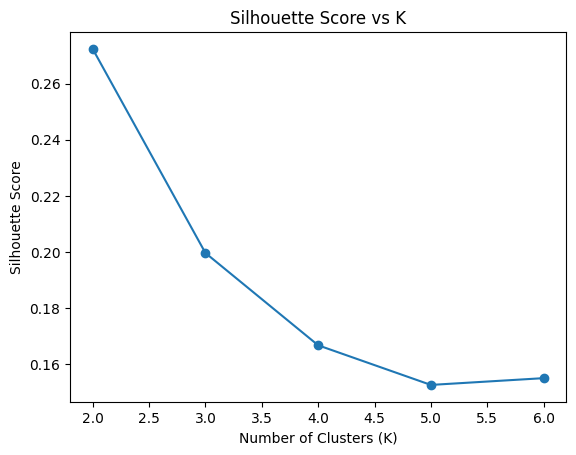

In [249]:
plt.plot(silhouette_df.index, silhouette_df['Silhouette_Score'], marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

The elbow method suggest 2 to 4 clusters which might provide us with the meaningfull clusters. The elbow is mostly noticable around 3 and 4, after that there is little little drop.

From above chart we found that the silhouette score is low for all clusters (which is k=2 , only 0.27) which might indicates that there is significant overlapping in the segments. The silhouette score for 3 is the second highest suggesting we should experiment with the clusters before finalizing them.

### Checking K=2 

In [250]:
# Checking if  2 clusters  are usefull for drawing new customer segments
Kmeans_2 = KMeans(n_clusters=2,random_state=42)
df['Cluster_2'] = Kmeans_2.fit_predict(df_scaled)

print('Cluster_size: (k=2)')
print(df['Cluster_2'].value_counts())

print('\n Cluster mean profiling(k=2):')
cluster2_profiling =df.groupby('Cluster_2')[model_features].mean()
print(cluster2_profiling)

Cluster_size: (k=2)
Cluster_2
1    1144
0    1093
Name: count, dtype: int64

 Cluster mean profiling(k=2):
             Recency  Customer_Tenure_Days  Total_Purchases  \
Cluster_2                                                     
0          49.004575            328.689844         9.166514   
1          49.200175            377.771853        20.320804   

           Log_Avg_Order_Value  Deal_Ratio  Web_channel_ratio  children  
Cluster_2                                                                
0                     2.377718    0.265146           0.248690   1.36505  
1                     3.869082    0.099534           0.284093   0.55507  


Dividing the customer persona's in 2 clusters may mathematically be efficient to split them in high spenders vs low spenders. But this is useless for marketing. We have to find the distinct customer segments for efficient marketing.

### Checking K=3

In [251]:
# Checking for 3 clusters
kmeans_3 = KMeans(n_clusters=3, random_state=42)
df['Cluster_3'] = kmeans_3.fit_predict(df_scaled)

print("Cluster sizes (K=3):")
print(df['Cluster_3'].value_counts())

print("\nCluster means (K=3):")
cluster3_profile =df.groupby('Cluster_3')[model_features].mean()
print(cluster3_profile)

Cluster sizes (K=3):
Cluster_3
1    1068
0     600
2     569
Name: count, dtype: int64

Cluster means (K=3):
             Recency  Customer_Tenure_Days  Total_Purchases  \
Cluster_3                                                     
0          25.035000            308.913333         8.653333   
1          48.886704            379.373596        20.598315   
2          74.894552            353.093146        10.676626   

           Log_Avg_Order_Value  Deal_Ratio  Web_channel_ratio  children  
Cluster_3                                                                
0                     2.353222    0.250875           0.246204  1.243333  
1                     3.910970    0.093125           0.282711  0.520599  
2                     2.524125    0.270102           0.258634  1.449912  


3 clusters might be helpfull by separating active and inactive budget customers which can be seen in cluster 0(active budget families) and 2(at risk of churn). and cluster 1 shows recent premium loyal customers who have high purchase frequency ,high order value and low deal dependency and children count. The 3 cluster-segments does not show new behavioral type- it mainly adds lifecycle distinction like if a customer is active or inactive.

### Checking k=4

In [252]:
# K = 4
kmeans_4 = KMeans(n_clusters=4, random_state=42)
df['Cluster_4'] = kmeans_4.fit_predict(df_scaled)

# Cluster size
print("Cluster sizes (K=4):")
print(df['Cluster_4'].value_counts())

# Cluster mean profiling
print("\nCluster means (K=4):")
cluster4_profile = df.groupby('Cluster_4')[model_features].mean()
print(cluster4_profile)

Cluster sizes (K=4):
Cluster_4
3    617
1    579
0    529
2    512
Name: count, dtype: int64

Cluster means (K=4):
             Recency  Customer_Tenure_Days  Total_Purchases  \
Cluster_4                                                     
0          24.429112            293.202268         8.100189   
1          47.846287            448.445596        20.412781   
2          75.121094            343.855469         9.273438   
3          49.852512            325.155592        20.119935   

           Log_Avg_Order_Value  Deal_Ratio  Web_channel_ratio  children  
Cluster_4                                                                
0                     2.288236    0.256082           0.236994  1.257089  
1                     3.559395    0.151032           0.359963  0.989637  
2                     2.401974    0.270497           0.246797  1.439453  
3                     4.090597    0.068496           0.221511  0.246353  


These clusters shows clear interpretable  customer segments that might be beneficial for marketing.

below persona's can be concluded from above stats:

    1. The premium loyal customers(cluster 3):
        1.these have the highest avg order value 
        2.lowest deal dependency
        3.fewest or almost no children
        4.moderate recency and low web reliance
        
    STRATEGY: Exclusive offers, premimum products, and early access campaigns can be offered to these customers to keep them loyal.
        
    2. loyal digitally literate customers(clusters 1):
        1. These are the high purchase customers
        2. These have the longest tenure
        3. have the highest web usage
        4. have moderate deal sensitivity 
        5. and have moderate family size
        
     STRATEGY: Website loyalty programs , bundles or subscription models can be offered to them.
     
    3. Active bargain hunters( cluster 0):
        1. These are the recent customers and have recent purchases
        2. Have low avg order value
        3. These are family oriented customers
        4. Have high deal usage 
        
     STRATEGY: These customers are highly engaged but price sensitive. Flash sales , coupens, promotional reminders might make them frequent and long term buyers.
     
     4.AT RISK Customers( cluster 2):
         1.These have the high recency around 75 days(more than 2 months)
         2.high deal usage
         3. have large families
         4. and have low order value
         
     STRATEGY: These are similar to active bargain hunter but are disengaging. Reactivation campaigns, strong discount incentives might be beneficial.

# Final KMeans Model With 4 clusters

In [253]:
# Finalizing the clusters
kmeans_final = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans_final.fit_predict(df_scaled)

In [254]:
# silhouette score of kmeans

kmeans_sil = silhouette_score(df_scaled,df['Cluster'])
print('Kmeans silhouette:  ', kmeans_sil)

Kmeans silhouette:   0.16678028563000605


### Cluster Profiling- FInal

In [255]:
print("\nCluster final k-means (K=4):")
cluster_profile_final = df.groupby('Cluster')[model_features].mean()
print(cluster_profile_final)


Cluster final k-means (K=4):
           Recency  Customer_Tenure_Days  Total_Purchases  \
Cluster                                                     
0        24.429112            293.202268         8.100189   
1        47.846287            448.445596        20.412781   
2        75.121094            343.855469         9.273438   
3        49.852512            325.155592        20.119935   

         Log_Avg_Order_Value  Deal_Ratio  Web_channel_ratio  children  
Cluster                                                                
0                   2.288236    0.256082           0.236994  1.257089  
1                   3.559395    0.151032           0.359963  0.989637  
2                   2.401974    0.270497           0.246797  1.439453  
3                   4.090597    0.068496           0.221511  0.246353  


In [256]:
# Mapping the clusters to the derived segments
cluster_map = {
    0:'Active_Bargain_Hunters',
    1:'Loyal_Web_Parents',
    2:'At_Risk_Cutomers',
    3:'Premium_Loyal_Customers'
}

df['Cluster_Name'] = df['Cluster'].map(cluster_map)

In [257]:
df['Cluster_Name']

0             Loyal_Web_Parents
1        Active_Bargain_Hunters
2       Premium_Loyal_Customers
3        Active_Bargain_Hunters
4              At_Risk_Cutomers
                 ...           
2235          Loyal_Web_Parents
2236           At_Risk_Cutomers
2237    Premium_Loyal_Customers
2238    Premium_Loyal_Customers
2239           At_Risk_Cutomers
Name: Cluster_Name, Length: 2237, dtype: object

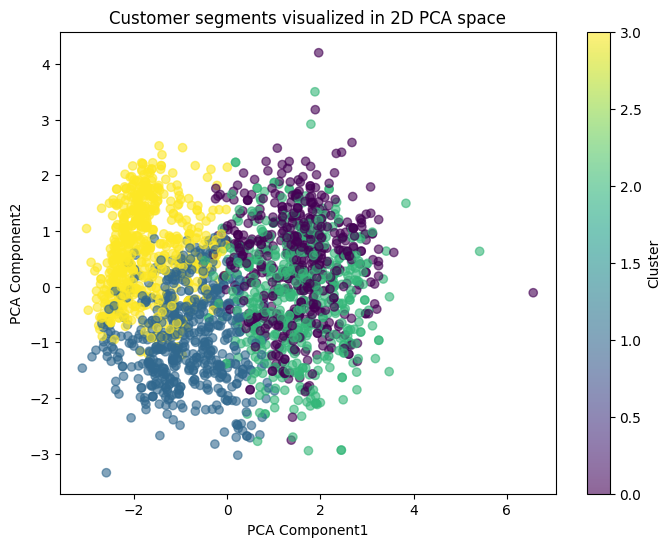

In [258]:

pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)

df['PCA1'] = pca_components[:,0]
df['PCA2'] = pca_components[:,1]

plt.figure(figsize=(8,6))
plt.scatter(df['PCA1'],df['PCA2'], c= df['Cluster'],cmap ='viridis',alpha=0.6)
plt.xlabel("PCA Component1")
plt.ylabel("PCA Component2")
plt.title('Customer segments visualized in 2D PCA space')
plt.colorbar(label= 'Cluster')
plt.show()

The PCA scatterplot shows:

    1.One cluster appears clearly more separated from the others.

    2.The remaining clusters exhibit partial overlap.

This supports the idea that the segmentation is strategic rather than naturally discrete.

In [259]:
pca.explained_variance_ratio_

array([0.38601057, 0.16561186])

The first two principal components explain approximately 55% of the total variance (38.6% + 16.6%).

Insight:
This indicates that the 2D PCA visualization captures more than half of the behavioral variation in the dataset. While not exhaustive, it provides a reasonably representative view of cluster structure.

In [260]:
pd.DataFrame(kmeans_final.cluster_centers_, columns=model_features)

,Recency,Customer_Tenure_Days,Total_Purchases,Log_Avg_Order_Value,Deal_Ratio,Web_channel_ratio,children
0,-0.851678,-0.301038,-0.881908,-0.938693,0.681498,-0.300901,0.410501
1,-0.045482,0.468175,0.719079,0.459256,-0.264483,0.930583,0.049349
2,0.898682,-0.049160,-0.729311,-0.813139,0.809098,-0.199492,0.649882
3,0.025835,-0.141691,0.683936,1.046335,-1.005979,-0.451739,-0.936964


Based on cluster centers, the strongest differentiating variables are:

    1.Deal_Ratio

    2.Log_Avg_Order_Value

    3.Recency

    4.Web_channel_ratio

Insight:
Segmentation is primarily driven by spending intensity, discount sensitivity, engagement recency, and channel behavior — not by income directly (income was used only for validation).

### Income  Validation w.r.t.  Clusters

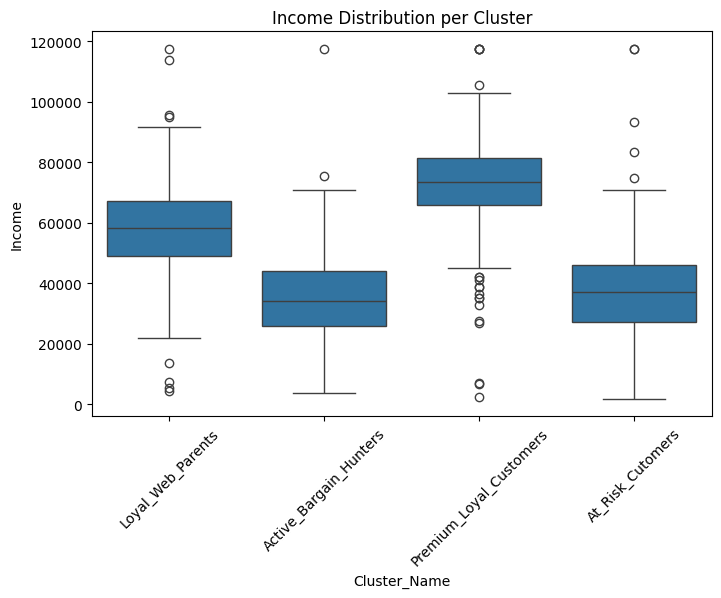

In [261]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster_Name', y='Income', data=df)
plt.title("Income Distribution per Cluster")
plt.xticks(rotation=45)
plt.show()

In [262]:
df.groupby('Cluster_4')['Income'].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster_4,,,,,,,,
0,529.0,35115.846881,13255.158318,3502.0,25965.0,34176.0,44051.0,117418.0
1,579.0,57735.890328,14525.547837,4428.0,48997.0,58275.0,67178.0,117418.0
2,512.0,37152.416016,14396.554475,1730.0,27112.0,36958.0,46098.0,117418.0
3,617.0,72887.874392,13215.757360,2447.0,65695.0,73455.0,81217.0,117418.0


from above boxplot and stats our clusters map with the data. We successfully identified the four distinct income based persona's. however we noticed an anomaly : You can see the max column showing the same max value, these might be due to the result of the outlier capping methodology which capped our outliers to the 117k value.

### campaign response rate per cluster

In [263]:
df.groupby('Cluster_Name')['Response'].mean().sort_values(ascending=False)

Cluster_Name
Premium_Loyal_Customers    0.230146
Loyal_Web_Parents          0.157168
Active_Bargain_Hunters     0.143667
At_Risk_Cutomers           0.048828
Name: Response, dtype: float64

### Total spending per cluster

In [264]:
df.groupby('Cluster_Name')['Total_spending'].mean().sort_values(ascending=False)

Cluster_Name
Premium_Loyal_Customers    1255.833063
Loyal_Web_Parents           784.516408
At_Risk_Cutomers            139.623047
Active_Bargain_Hunters      102.981096
Name: Total_spending, dtype: float64

In [265]:
cluster_size = df['Cluster'].value_counts(normalize=True) * 100
cluster_size.sort_index()

Cluster
0    23.647743
1    25.882879
2    22.887796
3    27.581582
Name: proportion, dtype: float64

# Heirarchial/ Agglomerative model

In [266]:
agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(df_scaled)
agg_silhouette = silhouette_score(df_scaled,agg_labels)

print("Agglomerative silhouette score: ", agg_silhouette)

Agglomerative silhouette score:  0.12219702133167999


Gaussian mixture model(GMM)

# Gaussian Mixture model(GMM)

In [267]:
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(df_scaled)
gmm_silhouette = silhouette_score(df_scaled, gmm_labels)

print("GMM silhouette score: ", gmm_silhouette)

GMM silhouette score:  0.17562405249612473


## Comparison Of models

In [268]:
comparison = {
    "KMeans": kmeans_sil,
    "Agglomerative": agg_silhouette,
    "GMM": gmm_silhouette
}

comparison

{'KMeans': 0.16678028563000605,
 'Agglomerative': 0.12219702133167999,
 'GMM': 0.17562405249612473}

##### Insights:

Gaussian Mixture Model achieved the highest silhouette score, though the improvement over KMeans is marginal (~0.009 difference). Hierarchical clustering performed notably worse, suggesting the absence of a strong nested cluster structure.


##### Model Selection
    Although GMM achieved the highest silhouette score, the improvement over KMeans was minimal. Given:

    1.Comparable clustering quality
    2.Simpler interpretability
    3.Strong business alignment

KMeans was retained as the final segmentation model.

# Saving the model

In [269]:
import joblib

joblib.dump(kmeans_final,'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(model_features, 'model_features.pkl')

['model_features.pkl']

In [272]:
# Save the Updated Excel or csv
raw_columns = [
    "ID",
    "Recency",
    "Customer_Tenure_Days",
    "Total_Purchases",
    "Avg_Order_Value",
    "Deal_Ratio",
    "Web_channel_ratio",
    "children"
]

df[raw_columns].to_csv("customer_raw_dataset.csv", index=False)

In [273]:
# Excel updated with all features
df.to_excel("Customer_data_All_Features.xlsx", index=False)

# Limitations

1.Silhouette scores indicate moderate cluster separation, suggesting customer behavior forms a continuum rather than clearly distinct natural groups.

2.PCA visualization confirms partial overlap among mid- and low-value clusters.

3.Segmentation results are sensitive to feature selection and scaling.

4.Income was not used in clustering but only for validation; therefore, economic differentiation emerges indirectly.

These limitations suggest that clusters should be interpreted as strategic marketing segments rather than rigid behavioral categories.

# Conclusion

This analysis applied KMeans clustering to segment customers based on behavioral metrics including recency, purchase frequency, order value, discount sensitivity, and channel usage.

Model evaluation using elbow and silhouette methods indicated that while K=2 provided the strongest statistical separation, K=4 offered greater strategic granularity. Despite moderate silhouette scores, the segmentation successfully isolated a structurally distinct high-value cluster and differentiated customers by engagement and price sensitivity.

Key findings:

    1.A clearly defined Premium segment exhibits high spending, low discount dependency, and strong economic value.

    2.A digitally engaged loyal segment shows high web usage and long-term retention.

    3.Lower-value segments are differentiated primarily by engagement state (active vs at-risk).
    
    
   Overall, the segmentation provides actionable strategic insights while maintaining transparency regarding statistical limitations.